Visualize activations for neurons in `extra_addition_neurons.json` that did **not** make it into `neurons_per_task.json["addition"]`.

In [1]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 12

In [2]:
import torch
from nnsight import LanguageModel
model = LanguageModel("meta-llama/Llama-3.1-8B", dispatch=True, device_map="cuda")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [3]:
import json

with open('./neurons_per_task.json', 'r') as f:
    neurons_per_task = json.load(f)

with open('./extra_addition_neurons.json', 'r') as f:
    extra_addition_neurons = json.load(f)

addition_set = set(neurons_per_task["addition"])
missed_neurons = [n for n in extra_addition_neurons if n not in addition_set]
print(f"{len(missed_neurons)} missed neurons: {missed_neurons}")

12 missed neurons: [11942, 14013, 4549, 4040, 11991, 9695, 14305, 2405, 2923, 7790, 3187, 1658]


Collect last-token activations at layer 18 MLP down_proj input across all task prompts, then average per output value.

In [4]:
import itertools
import seaborn as sns
import numpy as np
from tasks import TASKS

task = "addition"
num_to_idx = TASKS[task]["num_to_idx"]

all_prompts = []
causal_model = TASKS[task]["causal_model"]
input_vars = causal_model.inputs
input_value_lists = [causal_model.values[v] for v in input_vars]

for combo in itertools.product(*input_value_lists):
    inp = dict(zip(input_vars, combo))
    result = causal_model.run_forward(inp)
    all_prompts.append({**result, **inp})

try:
    premods = [d["premod"] for d in all_prompts]
except KeyError:
    assert task == "addition"
    premods = [int(d["output"]) for d in all_prompts]

prompts = [d["raw_input"] for d in all_prompts]

with torch.no_grad():
    with model.trace(prompts):
        neuron_activations = model.model.layers[18].mlp.down_proj.input[:, -1].save()

premod_avgs = {pm: torch.zeros(neuron_activations.shape[-1]).cuda() for pm in premods}
premod_cts = {pm: 0 for pm in premods}
for premod_label, nas in zip(premods, neuron_activations):
    premod_avgs[premod_label] += nas
    premod_cts[premod_label] += 1
premod_avgs = {k: v / premod_cts[k] for k, v in premod_avgs.items()}

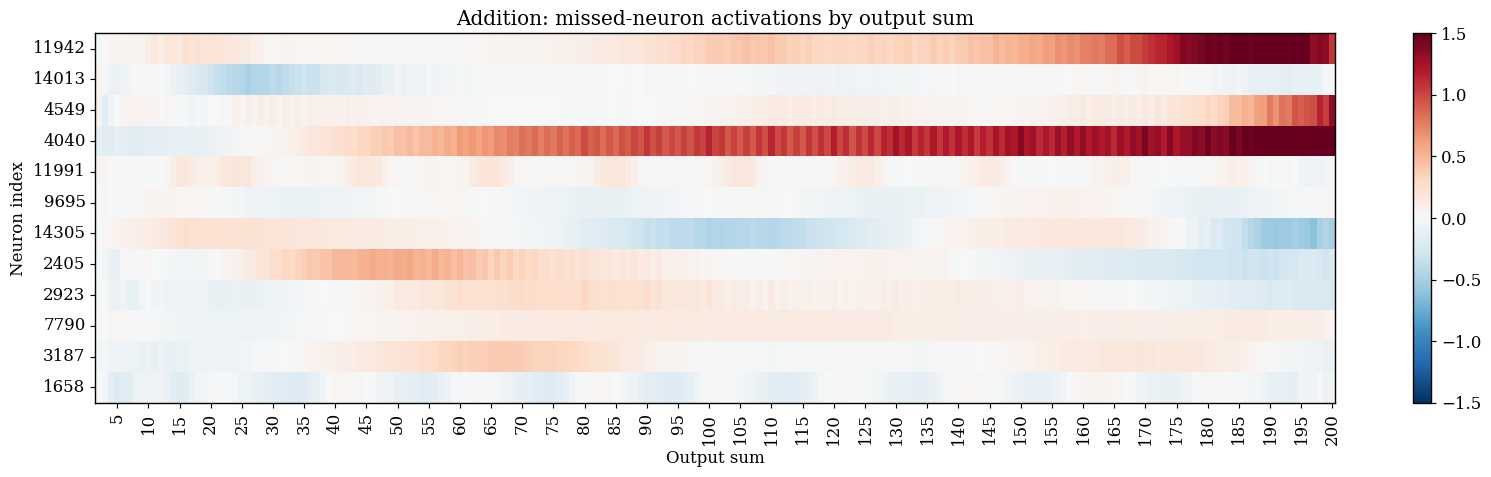

In [8]:
if task == "months":
    x = list(range(2, 37))
elif task == "addition":
    x = list(range(2, 201))
elif task == "weekdays":
    x = list(range(2, 22))
elif task == "hours":
    x = list(range(1, 72))

heatmap_data = []
for neuron_idx in missed_neurons:
    row = [premod_avgs[output_sum][neuron_idx].item() for output_sum in x]
    heatmap_data.append(row)
heatmap_data = np.array(heatmap_data)

vmax = 1.5

ylabels = [str(n) for n in missed_neurons]

fig, ax = plt.subplots(figsize=(20, max(4, 0.4 * len(missed_neurons))))
sns.heatmap(
    heatmap_data,
    xticklabels=False,
    yticklabels=ylabels,
    cmap='RdBu_r',
    center=0,
    ax=ax,
    rasterized=True,
    vmax=vmax,
    vmin=-vmax
)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
tick_positions = [i + 0.5 for i, v in enumerate(x) if v % 5 == 0]
tick_labels = [v for v in x if v % 5 == 0]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90)
ax.set_xlabel("Output sum")
ax.set_ylabel("Neuron index")
ax.set_title(f"{task.title()}: missed-neuron activations by output sum")

ax.collections[0].colorbar.outline.set_visible(True)
ax.collections[0].colorbar.outline.set_linewidth(1)
plt.savefig("../missed_neurons_activations.pdf")

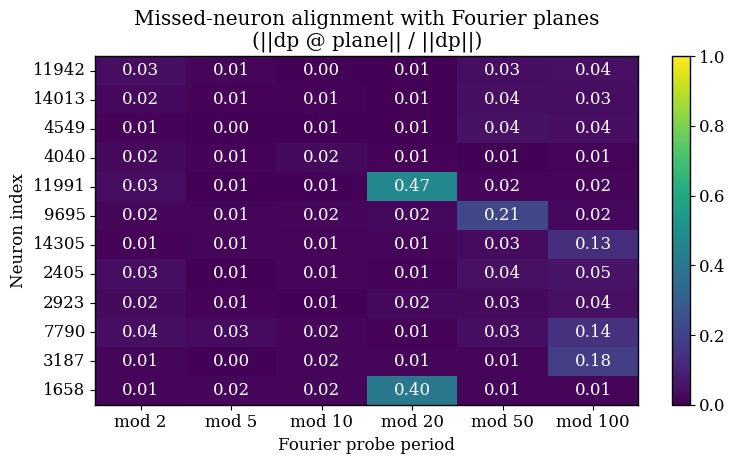

In [7]:
import os

PROBES_DIR = "fourier_probes/addition_probes_layer_18_last_token_resid/"

def load_probe(period, func_name):
    path = os.path.join(PROBES_DIR, f"probe_period{period}_{func_name}.pt")
    sd = torch.load(path, map_location="cpu", weights_only=True)
    return sd["linear.weight"].squeeze(0).float()  # (4096,)

periods = [2, 5, 10, 20, 50, 100]
fourier_probes_cos = {p: load_probe(p, "cos") for p in periods}
fourier_probes_sin = {p: load_probe(p, "sin") for p in periods}

# define Fourier planes
fourier_planes = {}
with torch.no_grad():
    for k in fourier_probes_cos.keys():
        cos, sin = fourier_probes_cos[k], fourier_probes_sin[k]
        stacked = torch.stack([cos, sin]).T  # (4096, 2)
        orthonormd, _, _ = torch.linalg.svd(stacked, full_matrices=False)
        fourier_planes[k] = orthonormd

# W_down[:, n] is the residual-stream direction neuron n writes into
down_projs = model.model.layers[18].mlp.down_proj.weight.detach().float().cpu()  # (4096, 14336)

with torch.no_grad():
    all_alignments = {}
    for neuron_idx in missed_neurons:
        dp = down_projs[:, neuron_idx]
        alignments = []
        for period, fplane in fourier_planes.items():
            alignments.append(
                (period, (torch.norm(dp @ fplane) / torch.norm(dp)).item())
            )
        all_alignments[neuron_idx] = alignments

alignment_matrix = np.array([
    [dict(all_alignments[n])[p] for p in periods]
    for n in missed_neurons
])

fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(missed_neurons))))
sns.heatmap(
    alignment_matrix,
    xticklabels=[f"mod {p}" for p in periods],
    yticklabels=[str(n) for n in missed_neurons],
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    ax=ax,
)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Fourier probe period")
ax.set_ylabel("Neuron index")
ax.set_title("Missed-neuron alignment with Fourier planes\n(||dp @ plane|| / ||dp||)")
ax.collections[0].colorbar.outline.set_visible(True)
ax.collections[0].colorbar.outline.set_linewidth(1)
plt.tight_layout()
plt.savefig("../outputs/missed_neurons_fplane.pdf")